# What a Gaussian likelihood cannot marginalise

A Gaussian-likelihood moment-tensor inversion fixes the source at the catalogue depth and location, trusts the
one-dimensional arrival times and amplitudes, and assumes every station is healthy. A neural posterior trained on
simulations in which none of that is assumed carries those uncertainties into its answer. This notebook does both
for the 2019-07-04 Ridgecrest foreshock (Mw 6.4) at eight regional stations, 20-50 s, tests the two posteriors on
the same held-out simulations, and then applies them to the recorded data.

The event, stations and data are those of the ObsPy example (`ridgecrest_obspy.ipynb`); the nuisances are
introduced one by one in `nuisances.ipynb`. The forward model is the Instaseis database `prem_a_20s`. The notebook
simulates 10,000 sources and trains a network on the GPU: on this machine, generation takes 2 min on eight cores
and training 13 min on one RTX A6000.

**On Google Colab**, choose a GPU runtime (Runtime > Change runtime type > T4 GPU) and run all cells. The first
cell clones the repository and installs the package, Instaseis, ObsPy and Basemap with pip; the second downloads
the database (869 MB). Generation takes about 7 min on Colab's two cores (measured here with two processes) and
training an estimated 20 min on a T4 (not measured). The notebook has not been run on Colab itself.

In [1]:
import sys

if "google.colab" in sys.modules:
    !git clone --depth 1 https://github.com/asaoulis/seismo-sbi
    !pip install -q "./seismo-sbi[ml]" obspy instaseis basemap
    %cd seismo-sbi/examples

In [2]:
import hashlib
import os
import tempfile
import urllib.request
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from mpl_toolkits.basemap import Basemap
from obspy import read, read_events, read_inventory
from scipy.stats import chi2

from seismo_sbi.data_handling.preprocessing.processing import deconvolve_and_filter
from seismo_sbi.data_handling.preprocessing.sbi_export import observation_from_stream, pre_event_autocorrelations
from seismo_sbi.data_quality.metrics import align_best_lag, variance_reduction
from seismo_sbi.evaluation.posterior_metrics import tarp_coverage
from seismo_sbi.moment_tensor.comparison import kagan_batch, pyrocko_mt
from seismo_sbi.moment_tensor.conventions import moment_magnitude
from seismo_sbi.moment_tensor.lune_angles import mts6_to_gamma_delta
from seismo_sbi.moment_tensor.quakeml import moment_tensor_from_tensor, source_location_from_origin
from seismo_sbi.nuisance_effects.amplitude_effect import AmplitudeErrorEffect
from seismo_sbi.nuisance_effects.scattering_coda_effect import ScatteringCodaEffect
from seismo_sbi.nuisance_effects.time_shift_effect import TimeShiftErrorEffect
from seismo_sbi.plotting.lune import plot_kde_contours_on_lune, plot_lune_frame, plot_scatter_on_lune
from seismo_sbi.plotting.rocko_beachball_patch import plot_beachball_on_axes
from seismo_sbi.sbi.configuration import SBI_Configuration
from seismo_sbi.sbi.datasets.training_data import build_pipeline, generate_training_dataset, prepare_training_data
from seismo_sbi.sbi.noises.toeplitz_covariances import BlockDiagonalEmpiricalCovariance
from seismo_sbi.sbi.npe.data.dataloading import TorchSimulationDataset
from seismo_sbi.sbi.npe.source_conditioning import pack_subset_observation
from seismo_sbi.sbi.npe.training.train import CompressionTrainer, attach_loggers
from seismo_sbi.simulators.instaseis.simulator import InstaseisSourceSimulator
from seismo_sbi.simulators.simulation_io import seismogram_map_to_array
from seismo_sbi.utils.seismograms import shift_1d_with_padding

DATABASE_URL = "https://github.com/asaoulis/seismo-sbi/releases/download/prem_a_20s/merged_output.nc4"
DATABASE_SHA256 = "171166f9b38e624fc13dffdee601071e8ccafeabb0a629586bb985c7218d48da"

def resolve_database():
    """The ``prem_a_20s`` directory: ``INSTASEIS_DB_20S`` if set, else a checked download into the user cache."""
    path = Path.home() / ".cache" / "seismo_sbi" / "prem_a_20s" / "merged_output.nc4"
    if "INSTASEIS_DB_20S" not in os.environ and not path.exists():
        path.parent.mkdir(parents=True, exist_ok=True)
        urllib.request.urlretrieve(DATABASE_URL, path)
        assert hashlib.sha256(path.read_bytes()).hexdigest() == DATABASE_SHA256, "corrupt database download"
    return os.environ.get("INSTASEIS_DB_20S", str(path.parent))

DATABASE = resolve_database()
CONFIG_PATH = "configs/npe_flagship.yaml"
SAMPLING_RATE_HZ = 0.5

## 1. The event, the stations and the published solutions

Five agencies published a moment tensor for this earthquake. They agree on a strike-slip mechanism and differ in
depth (8 to 13.5 km), Mw (6.32 to 6.47) and double-couple fraction. The eight stations are 2 to 4 degrees away.
The rupture is about 15-20 km long and lasts about 8 s; at 20-50 s the wavelengths are 70 km and more and the
periods several source durations, so the waves see a point source at the centroid.

The data are prepared as in the ObsPy example: response removed, rotated to north and east, band-passed at
20-50 s, 0.5 Hz, from 60 s before the origin time to 290 s after it. The noise covariance comes from the 1200 s
before that window.

8 of 8 stations, 176 samples per trace; published: SCSN Mw 6.39, USGS Mw 6.47, USGS Mw 6.32, GCMT Mw 6.45, GFZ Mw 6.41


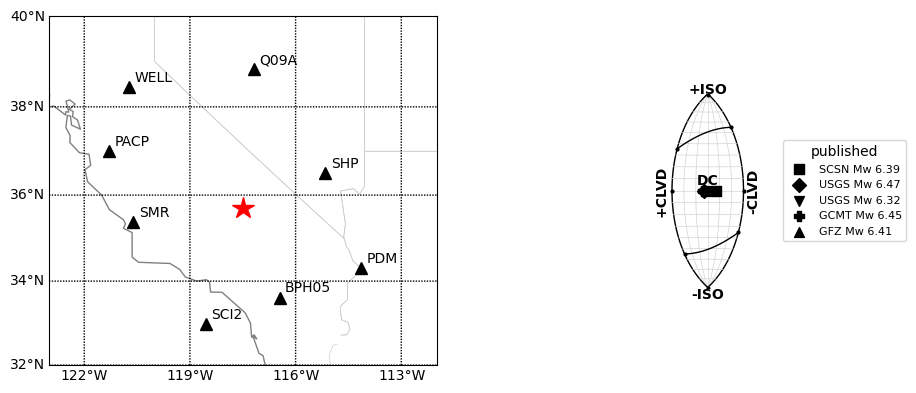

In [3]:
config = SBI_Configuration.from_file(CONFIG_PATH, output_directory=tempfile.mkdtemp(), database_path=DATABASE)
config_block = config.raw_config
receivers = config.sim_parameters.receivers
names = [receiver.station_name for receiver in receivers]
station_coordinates = receivers.get_station_locations_array()[:, :2]

catalogue = read_events("data/ridgecrest/events.xml.gz")
hypocentre = catalogue[0].preferred_origin()
published = {}
for mechanism in (m for event in catalogue for m in event.focal_mechanisms if m.moment_tensor and m.moment_tensor.tensor):
    m6 = moment_tensor_from_tensor(mechanism.moment_tensor.tensor)
    agency = {"us": "USGS", "CI": "SCSN"}.get(mechanism.creation_info.agency_id, mechanism.creation_info.author)
    if not any(np.allclose(m6, other, rtol=1e-3) for other in published.values()):
        published[f"{agency} Mw {moment_magnitude(m6):.2f}"] = m6
gcmt = next(m for m in catalogue[1].focal_mechanisms if m.creation_info.author == "GCMT")
centroid = source_location_from_origin(gcmt.moment_tensor.derived_origin_id.get_referred_object(),
                                       origin_time_utc=hypocentre.time)

raw, inventory = read("data/ridgecrest/waveforms.mseed"), read_inventory("data/ridgecrest/stations.xml.gz")
processed = deconvolve_and_filter(raw, inventory, filter_kwargs=dict(freqmin=0.02, freqmax=0.05), target_sr=SAMPLING_RATE_HZ)
window = (hypocentre.time - 60, hypocentre.time + 290)
observed, present = observation_from_stream(processed, receivers, window, SAMPLING_RATE_HZ, stacked=True)
n_samples = observed.shape[-1]
noise_covariance = BlockDiagonalEmpiricalCovariance(
    pre_event_autocorrelations(processed, names, window[0], 1200.0), receivers, n_samples, num_jobs=1)
print(f"{present.sum()} of {len(names)} stations, {n_samples} samples per trace; published:", ", ".join(published))

def dc_distance_deg(m6):
    """Great-circle distance (deg) on the lune from the double-couple point."""
    gamma, delta = np.radians(mts6_to_gamma_delta(np.atleast_2d(m6)))
    return np.degrees(np.arccos(np.cos(gamma) * np.cos(delta)))

def draw_published(ax, lune, size=50):
    for (label, m6), marker in zip(published.items(), "sDvP^"):
        plot_scatter_on_lune(ax, lune, *mts6_to_gamma_delta(m6[None]), marker=marker, color="k", s=size, label=label, zorder=5)

fig, (ax_map, ax_lune) = plt.subplots(1, 2, figsize=(11, 4.8))
region = Basemap(projection="merc", llcrnrlat=32, urcrnrlat=40, llcrnrlon=-123, urcrnrlon=-112, resolution="l", ax=ax_map)
region.drawcoastlines(color="0.5")
region.drawstates(color="0.8")
region.drawparallels(range(32, 41, 2), labels=[1, 0, 0, 0]), region.drawmeridians(range(-122, -111, 3), labels=[0, 0, 0, 1])
for receiver, (x, y) in zip(receivers, zip(*region(station_coordinates[:, 1], station_coordinates[:, 0]))):
    ax_map.plot(x, y, "k^", ms=8), ax_map.annotate(receiver.station_name, (x, y), xytext=(4, 4), textcoords="offset points")
ax_map.plot(*region(hypocentre.longitude, hypocentre.latitude), "r*", ms=16)
draw_published(ax_lune, plot_lune_frame(ax_lune))
ax_lune.legend(loc="center left", bbox_to_anchor=(0.68, 0.5), fontsize=8, title="published")
plt.show()

## 2. What the network is trained to expect

Every training simulation draws a source position and centroid time, a travel-time error per station, a site and
path amplification per trace, a scattered coda at some stations, and a random subset of stations and components
(`nuisances.ipynb` introduces each effect). The widths are those of `configs/npe_flagship.yaml`; the travel-time
widths are the scatter of the cross-correlation lags of these data against PREM synthetics, station by station.
The source duration is not among them: at 20-50 s on this database (4.9 s sample interval) an 8 s source time
function is unresolvable, and the centroid-time nuisance absorbs it. Below, 20 draws of each effect (colours) over
the synthetic of the GCMT tensor at the GCMT centroid (black), north component, nearest and farthest station.

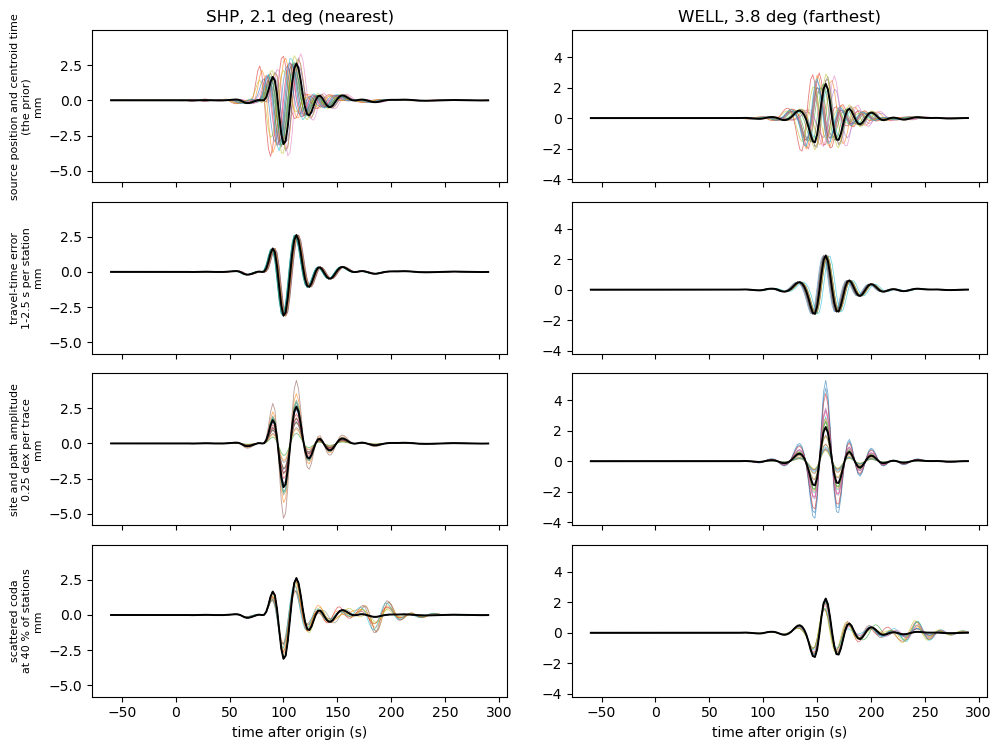

In [4]:
simulator = InstaseisSourceSimulator(DATABASE, components="ZEN", receivers=receivers, seismogram_duration_in_s=350.0,
                                     synthetics_processing=config_block["seismic_context"]["processing"])
gcmt_m6 = moment_tensor_from_tensor(gcmt.moment_tensor.tensor)
simulate = lambda source, m6=gcmt_m6: simulator.run_simulation({"source_location": list(source), "moment_tensor": list(m6)})[1]
nuisance = config_block["parameters"]["nuisance"]
options = lambda key: {k: v for k, v in nuisance[key].items() if k not in ("fiducial", "bounds", "stage")}
clean = simulate(centroid)
np.random.seed(0)
draws = {"source position and centroid time\n(the prior)":
         [simulate(np.random.uniform(*nuisance["source_location"]["bounds"])) for _ in range(20)]}
for label, effect, activation in [
        ("travel-time error\n1-2.5 s per station", TimeShiftErrorEffect(SAMPLING_RATE_HZ, **options("time_shift_error")), dict(time_shift_error=1.0)),
        ("site and path amplitude\n0.25 dex per trace", AmplitudeErrorEffect(**options("amplitude_error")), dict(amplitude_error=1.0)),
        ("scattered coda\nat 40 % of stations", ScatteringCodaEffect(**options("scattering_coda")), dict(scattering_coda=0.4))]:
    draws[label] = [effect(clean, receivers, **activation) for _ in range(20)]

time_s = np.arange(n_samples) / SAMPLING_RATE_HZ - 60.0
fig, axes = plt.subplots(len(draws), 2, figsize=(10, 1.9 * len(draws)), sharex=True, sharey="col")
for column, (station, title) in enumerate([("SHP", "SHP, 2.1 deg (nearest)"), ("WELL", "WELL, 3.8 deg (farthest)")]):
    for row, (label, maps) in zip(axes, draws.items()):
        row[column].plot(time_s, np.array([perturbed[station]["N"] for perturbed in maps]).T * 1e3, lw=0.6, alpha=0.6)
        row[column].plot(time_s, clean[station]["N"] * 1e3, "k", lw=1.4)
        row[0].set_ylabel(label + "\nmm", fontsize=8)
    axes[0, column].set_title(title)
    axes[-1, column].set_xlabel("time after origin (s)")
fig.tight_layout()
plt.show()

## 3. Why depth matters

The seismograms are linear in the six moment-tensor components, so at a fixed source position six simulations
give the kernels, and score compression with the noise covariance gives the Gaussian-likelihood posterior in
closed form: its mean is the weighted least-squares tensor and its covariance the inverse Fisher matrix. Fixing
the centroid at each depth from 2 to 20 km in turn gives a tight answer at every depth, and the answers move: the
magnitude and the source type depend on a depth the Gaussian likelihood has to assume, while the fit barely does.

      variance reduction    Mw  gamma (deg)  delta (deg)
2.0                 0.48  6.41         8.12       -49.08
4.0                 0.50  6.18        -9.72       -20.53
6.0                 0.51  6.16       -10.96         4.19
8.0                 0.51  6.18        -7.44        15.57
10.0                0.51  6.21        -5.16        20.38
12.0                0.51  6.23        -4.24        22.08
14.0                0.52  6.25        -4.25        21.54
16.0                0.52  6.29         0.15        25.59
18.0                0.52  6.30         1.23        29.02
20.0                0.51  6.32         1.57        31.86


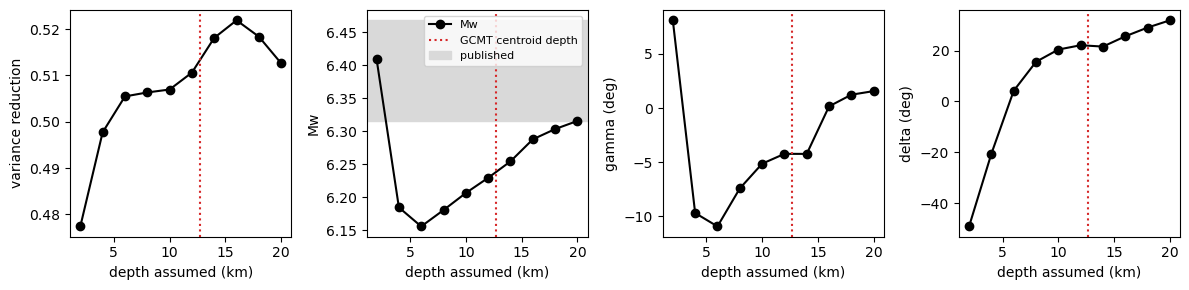

In [5]:
inverse_blocks = np.linalg.inv(noise_covariance.covariance_matrix_arrays).reshape(len(names), 3, n_samples, n_samples)

def kernels_at(source):
    """``(6, n_stations, 3, n_samples)`` synthetics of the six unit moment tensors at ``source``."""
    return np.array([seismogram_map_to_array(simulate(source, unit), receivers) for unit in np.eye(6)]).reshape(6, len(names), 3, -1)

def gaussian_posterior(data, kernels, stations=range(len(names))):
    """Mean ``(6,)`` and covariance ``(6, 6)`` (N m) for ``data`` ``(n_kept, 3, n_samples)`` recorded at ``stations``
    (indices); an all-zero trace is a missing component and is left out."""
    fisher, score = np.zeros((6, 6)), np.zeros(6)
    for row, station in enumerate(stations):
        for component in np.flatnonzero(np.abs(data[row]).sum(axis=1) > 0):
            weighted = kernels[:, station, component] @ inverse_blocks[station, component]
            fisher, score = fisher + weighted @ kernels[:, station, component].T, score + weighted @ data[row, component]
    return np.linalg.solve(fisher, score), np.linalg.inv(fisher)

depth_scan = {}
for depth_km in np.arange(2.0, 21.0, 2.0):
    kernels = kernels_at(centroid._replace(depth=depth_km))
    mean, _ = gaussian_posterior(observed, kernels)
    residual = observed - np.einsum("i,ijkl->jkl", mean, kernels)
    depth_scan[depth_km] = [1 - (residual ** 2).sum() / (observed ** 2).sum(), moment_magnitude(mean),
                            *np.ravel(mts6_to_gamma_delta(mean[None]))]
depth_scan = pd.DataFrame.from_dict(depth_scan, orient="index", columns=["variance reduction", "Mw", "gamma (deg)", "delta (deg)"])
print(depth_scan.round(2).to_string())
axes = depth_scan.plot(subplots=True, layout=(1, 4), figsize=(12, 3), marker="o", color="k", legend=False, sharex=True)[0]
for ax, label in zip(axes, depth_scan.columns):
    ax.axvline(centroid.depth, color="C3", ls=":", label="GCMT centroid depth")
    ax.set(xlabel="depth assumed (km)", ylabel=label)
axes[1].axhspan(*np.percentile([moment_magnitude(m6) for m6 in published.values()], [0, 100]), color="0.85", label="published")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. Simulate and train

The configuration samples 10,000 sources: a moment tensor oriented uniformly on the sphere with a
Gutenberg-Richter magnitude (b = 1) between Mw 5.9 and 6.9, the centroid anywhere within about 17 km of the
hypocentre, 2 to 20 km deep, 0 to 15 s after the hypocentral origin time. The travel-time errors and the coda are
drawn once per simulation; the amplitudes, the station and component subsets and the noise are drawn afresh every
time the network sees a simulation. The noise is drawn from the stations' own pre-event covariance, passed to the
data loader here because no configured noise model describes it; the configuration's white noise is a stand-in.

In [6]:
training = replace(config.training.apply_overrides(epochs=60), model_dim=64)
np.random.seed(2)
torch.manual_seed(2)
pipeline = build_pipeline(config, CONFIG_PATH)
simulation_paths = generate_training_dataset(pipeline, config, training.skip_compression_stencil)
data = prepare_training_data(pipeline, config, simulation_paths, training)
noise_sampler = noise_covariance.create_sampler()

Training dataset ready: 10000 simulations at /tmp/tmpj4ltktr_/sims/npe_flagship/results
Training-time nuisance augmentation: ['amplitude_error']
Post-noise augmentation: ['component_dropout']
Moment-tensor scaling: scale_shape


CSV metrics logging to /tmp/tmpj4ltktr_/npe_flagship/results/npe_flagship/metrics.csv
Found 10000 simulations matching *.h5 under /tmp/tmpj4ltktr_/sims/npe_flagship/results


[sim-cache] preloaded 10000 sims into RAM (0.17 GB, float32) in 44.3s — per-sample HDF5 load removed.


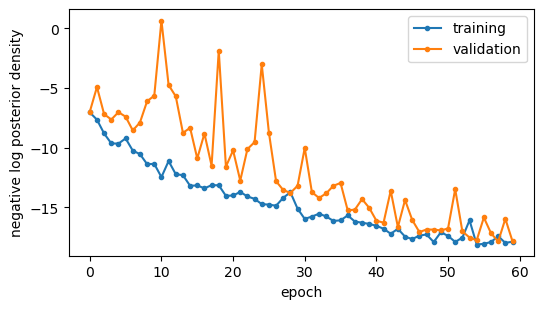

In [7]:
run_directory = pipeline.models_output_path / "npe_flagship"
trainer = CompressionTrainer.from_training_data(training, data, layers=2)
trainer.train("npe_flagship", epochs=training.epochs, output_path=pipeline.models_output_path,
              dataloader_args={**training.dataloader_args(pipeline, data), "synthetic_noise_model_sampler": noise_sampler},
              enable_progress_bar=False, logger=attach_loggers(training.logging, run_directory))
posterior = CompressionTrainer.from_run_directory(run_directory).build_posterior()
device = next(posterior.posterior_estimator.parameters()).device
losses = pd.read_csv(run_directory / "metrics.csv").groupby("epoch")[["loss", "val_loss"]].mean()
losses.columns = ["training", "validation"]
losses.plot(figsize=(6, 3.2), marker=".", xlabel="epoch", ylabel="negative log posterior density")
plt.show()

def npe_posterior(x, stations, n_draws=20000):
    """Posterior draws ``(n_draws, 6)`` (N m) for ``x`` ``(n_kept, 3, n_samples)`` recorded at ``stations``, and their
    log densities; the samples are drawn in the network's scaled units."""
    observation = pack_subset_observation(x, station_coordinates[stations]).to(device)
    draws = posterior.sample((n_draws,), x=observation, show_progress_bars=False)
    log_q = posterior.log_prob(draws, x=observation, norm_posterior=False).cpu().numpy()
    return data.data_scaler.inverse_transform(draws.cpu().numpy().astype(float)), log_q, observation

## 5. and 6. Calibration on held-out simulations, against the Gaussian likelihood

The last 10 % of the simulations were never trained on. Each is recorded by a random subset of the stations, with
every nuisance drawn as in training. The Gaussian likelihood is given the same observation, told which stations
and components are missing, the true noise covariance, and the GCMT centroid. For each posterior we find the
smallest highest-density region that contains the true tensor: a calibrated posterior's 95 % region holds the
truth 95 % of the time, at every level. The TARP test (Lemos et al. 2023) checks the network's samples the same
way without its density.

In [8]:
held_out_indices = range(int(training.batch.train_fraction * len(simulation_paths)), len(simulation_paths))[:500]
np.random.seed(3)
torch.manual_seed(3)
subsets = training.variable_stations.build_subsampler()
held_out = TorchSimulationDataset(**{**training.dataset_args(pipeline, data), "cache_in_memory": False,
                                     "synthetic_noise_model_sampler": noise_sampler,
                                     "fixed_item_masks": {index: (subsets(len(names)), None) for index in held_out_indices}})
centroid_kernels = kernels_at(centroid)


def predictive_misfit(x, stations, m6_draws, max_lag_s=10.0):
    """Median over ``m6_draws`` of 1 - variance reduction of their GCMT-centroid synthetics against the recorded
    traces of ``x`` ``(n_kept, 3, n_samples)``, each synthetic trace first shifted by its best lag within ``max_lag_s``."""
    recorded = np.abs(x).sum(axis=-1, keepdims=True) > 0
    max_lag = int(max_lag_s * SAMPLING_RATE_HZ)
    misfit = []
    for synthetic in np.einsum("ni,ijkl->njkl", m6_draws, centroid_kernels[:, stations]) * recorded:
        aligned = [[shift_1d_with_padding(s, align_best_lag(o, s, max_lag)[1]) for o, s in zip(*traces)] for traces in zip(x, synthetic)]
        misfit.append(1 - variance_reduction(x, np.array(aligned)))
    return np.median(misfit)


truths, misfits = [], []
levels, samples = {"NPE": [], "Gaussian likelihood": []}, {"NPE": [], "Gaussian likelihood": []}
for index in held_out_indices:
    theta, (x, _, _) = held_out[index]
    stations = held_out.fixed_item_masks[index][0]
    draws, log_q, observation = npe_posterior(x.numpy(), stations, 1000)
    log_q_truth = posterior.log_prob(theta[None].to(device), x=observation, norm_posterior=False).item()
    truth = data.data_scaler.inverse_transform(theta[None].numpy().astype(float))[0]
    mean, covariance = gaussian_posterior(x.numpy().astype(float), centroid_kernels, stations)
    levels["NPE"].append(np.mean(log_q > log_q_truth))
    levels["Gaussian likelihood"].append(chi2.cdf((truth - mean) @ np.linalg.solve(covariance, truth - mean), 6))
    samples["NPE"].append(draws)
    misfits.append((len(stations), predictive_misfit(x.numpy(), stations, draws[:20])))
    samples["Gaussian likelihood"].append(np.random.multivariate_normal(mean, covariance, 1000))
    truths.append(truth)
truths = np.array(truths)

Found 10000 simulations matching *.h5 under /tmp/tmpj4ltktr_/sims/npe_flagship/results


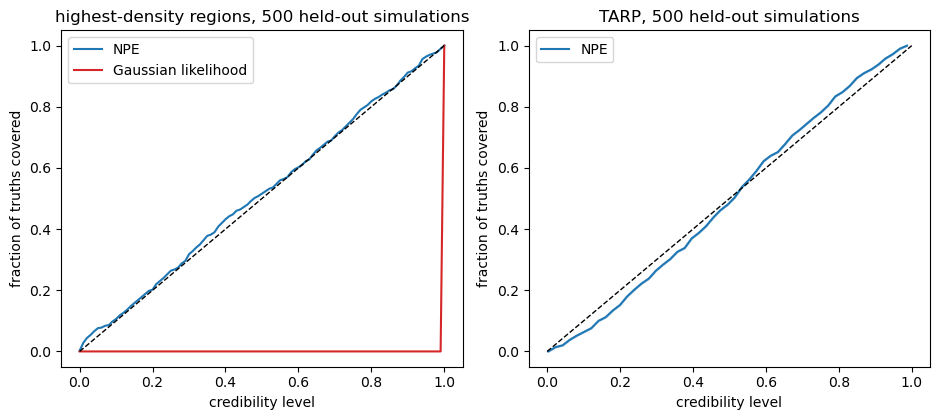

                                          NPE  Gaussian likelihood
truth inside the 95 % region            0.964                0.000
Mw 90 % interval width                  0.208                0.000
P(> 10 deg from DC), 46 near-DC truths  0.656                0.935


In [9]:
fig, (ax_hpd, ax_tarp) = plt.subplots(1, 2, figsize=(9.5, 4.3))
credibility = np.linspace(0, 1, 101)
near_dc, summary = dc_distance_deg(truths) < 10, {}
for (name, cloud), colour in zip(samples.items(), ("C0", "C3")):
    ax_hpd.plot(credibility, [np.mean(np.array(levels[name]) <= level) for level in credibility], color=colour, label=name)
    magnitudes = moment_magnitude(np.array(cloud).reshape(-1, 6)).reshape(len(truths), -1)
    summary[name] = {"truth inside the 95 % region": np.mean(np.array(levels[name]) <= 0.95),
                     "Mw 90 % interval width": np.median(np.ptp(np.percentile(magnitudes, [5, 95], axis=1), axis=0)),
                     f"P(> 10 deg from DC), {near_dc.sum()} near-DC truths": np.mean([np.mean(dc_distance_deg(c) > 10)
                                                                                     for c in np.array(cloud)[near_dc]])}
ecp, alpha = tarp_coverage(np.transpose(np.array(samples["NPE"]), (1, 0, 2)), truths)
ax_tarp.plot(alpha, ecp.mean(axis=0), color="C0", label="NPE")
ax_tarp.fill_between(alpha, *np.percentile(ecp, [5, 95], axis=0), color="C0", alpha=0.3)
for ax, title in ((ax_hpd, "highest-density regions"), (ax_tarp, "TARP")):
    ax.plot([0, 1], [0, 1], "k--", lw=1), ax.legend()
    ax.set(xlabel="credibility level", ylabel="fraction of truths covered", title=f"{title}, {len(truths)} held-out simulations")
plt.tight_layout()
plt.show()
print(pd.DataFrame(summary).round(3).to_string())
assert 0.88 <= summary["NPE"]["truth inside the 95 % region"] <= 0.99
assert summary["Gaussian likelihood"]["truth inside the 95 % region"] < 0.7

The Gaussian likelihood's posterior is as narrow as the noise allows: the travel-time errors, the amplitudes and
the source position it fixed move the data by far more than the noise, so its 95 % region almost never holds the
truth. The network, trained with those effects, gives a wider posterior that covers the truth at close to the
nominal rate.

## 7. The recorded earthquake

Both posteriors for the recorded data. The probabilities are posterior mass: on the lune, the mass within 10
degrees of the double-couple point and the mass with an isotropic part beyond 10 degrees of latitude; for each
published tensor, whether it lies in the network's 95 % region, and its Kagan angle to the posterior samples.
The beachballs are the published tensors (grey), the Gaussian-likelihood mean (red) and three draws from the
network's posterior (blue).

This posterior changes from one training to the next more than the held-out calibration would suggest. In two
trainings with this configuration, both calibrated on simulations, the mass within 10 degrees of a double couple
was 0.64 and 0.13, and 5 and 3 of the 5 published tensors lay inside the 95 % region. Three trainings disagree
about the recorded event (0.57, 0.12 and 0.71) more than about any of 150 held-out simulations, for 99 % of which
they agree within 0.50. The recorded data sit where the simulations do not fully reach, so each network
extrapolates differently, the more so because 10,000 simulations and 60 epochs are a very small training set for
a network of this kind; section 9 looks at the waveforms.

NPE                  Mw 6.42 to 6.63 (90 %); P(within 10 deg of DC) 0.66, P(delta > 10 deg) 0.09, P(delta < -10 deg) 0.13
Gaussian likelihood  Mw 6.24 to 6.24 (90 %); P(within 10 deg of DC) 0.00, P(delta > 10 deg) 1.00, P(delta < -10 deg) 0.00
published Mw: 6.39, 6.47, 6.32, 6.45, 6.41
SCSN Mw 6.39     in the NPE 95 % region: no ; Kagan angle to NPE samples 18.0 deg (median), to the Gaussian mean 21.5 deg
USGS Mw 6.47     in the NPE 95 % region: yes; Kagan angle to NPE samples 14.6 deg (median), to the Gaussian mean  9.5 deg


USGS Mw 6.32     in the NPE 95 % region: yes; Kagan angle to NPE samples 16.0 deg (median), to the Gaussian mean 11.7 deg
GCMT Mw 6.45     in the NPE 95 % region: yes; Kagan angle to NPE samples 18.6 deg (median), to the Gaussian mean 12.0 deg
GFZ Mw 6.41      in the NPE 95 % region: yes; Kagan angle to NPE samples 12.7 deg (median), to the Gaussian mean  7.4 deg


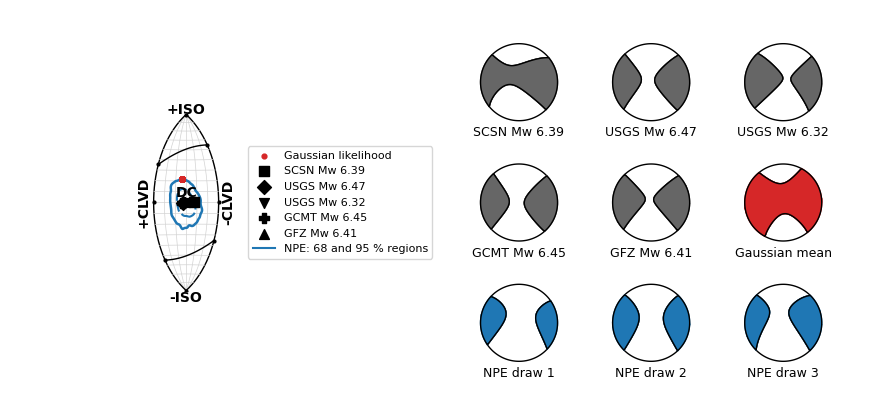

In [10]:
def describe(name, cloud):
    gamma, delta = mts6_to_gamma_delta(cloud)
    print(f"{name:20s} Mw {np.percentile(moment_magnitude(cloud), 5):.2f} to {np.percentile(moment_magnitude(cloud), 95):.2f} (90 %); "
          f"P(within 10 deg of DC) {np.mean(dc_distance_deg(cloud) < 10):.2f}, P(delta > 10 deg) {np.mean(delta > 10):.2f}, "
          f"P(delta < -10 deg) {np.mean(delta < -10):.2f}")

torch.manual_seed(4)
npe_m6, log_q, observation = npe_posterior(observed, range(len(names)))
gl_mean, gl_covariance = gaussian_posterior(observed, centroid_kernels)
gl_m6 = np.random.default_rng(4).multivariate_normal(gl_mean, gl_covariance, 20000)
describe("NPE", npe_m6), describe("Gaussian likelihood", gl_m6)
print("published Mw:", ", ".join(f"{moment_magnitude(m6):.2f}" for m6 in published.values()))
for label, m6 in published.items():
    log_q_published = posterior.log_prob(torch.as_tensor(data.data_scaler.transform(m6[None]), dtype=torch.float32).to(device),
                                         x=observation, norm_posterior=False).item()
    print(f"{label:16s} in the NPE 95 % region: {'yes' if log_q_published > np.quantile(log_q, 0.05) else 'no '}; Kagan angle "
          f"to NPE samples {np.median(kagan_batch(npe_m6[:4000], m6)):4.1f} deg (median), to the Gaussian mean {kagan_batch(gl_mean, m6)[0]:4.1f} deg")

fig, (ax_lune, ax_balls) = plt.subplots(1, 2, figsize=(11, 5), gridspec_kw={"width_ratios": [1, 1.2]})
lune = plot_lune_frame(ax_lune)
plot_kde_contours_on_lune(ax_lune, lune, *mts6_to_gamma_delta(npe_m6[:5000]), colors="C0")
plot_scatter_on_lune(ax_lune, lune, *mts6_to_gamma_delta(gl_m6[:200]), color="C3", s=12, label="Gaussian likelihood", zorder=6)
draw_published(ax_lune, lune)
ax_lune.plot([], [], color="C0", label="NPE: 68 and 95 % regions")
ax_lune.legend(loc="center left", bbox_to_anchor=(0.66, 0.5), fontsize=8)
balls = {**published, "Gaussian mean": gl_mean, **{f"NPE draw {k + 1}": npe_m6[k] for k in range(3)}}
ax_balls.set(xlim=(-0.6, 2.6), ylim=(-2.6, 0.6)), ax_balls.axis("off")
for k, (label, m6) in enumerate(balls.items()):
    plot_beachball_on_axes(ax_balls, pyrocko_mt(m6), k % 3, -(k // 3), diameter=0.2, linewidth=1,
                           color_t="C0" if "NPE" in label else "C3" if "Gauss" in label else "0.4")
    ax_balls.text(k % 3, -(k // 3) - 0.45, label, ha="center", fontsize=9)
plt.show()

## 8. Take stations away

The same network, without retraining, given only three of the eight stations: Q09A to the north, PDM to the
south-east and SMR to the west.

eight stations       Mw 6.42 to 6.63 (90 %); P(within 10 deg of DC) 0.66, P(delta > 10 deg) 0.09, P(delta < -10 deg) 0.13
three stations       Mw 6.41 to 6.64 (90 %); P(within 10 deg of DC) 0.54, P(delta > 10 deg) 0.13, P(delta < -10 deg) 0.19
median Kagan angle to GCMT: 18.6 deg 15.1 deg


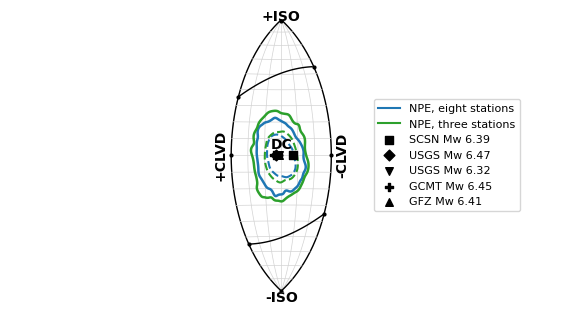

In [11]:
three = [names.index(station) for station in ("Q09A", "PDM", "SMR")]
torch.manual_seed(5)
npe_three = npe_posterior(observed[three], three)[0]
describe("eight stations", npe_m6), describe("three stations", npe_three)
print("median Kagan angle to GCMT:", *(f"{np.median(kagan_batch(cloud[:4000], gcmt_m6)):.1f} deg" for cloud in (npe_m6, npe_three)))
fig, ax = plt.subplots(figsize=(7, 5))
lune = plot_lune_frame(ax)
for cloud, colour, label in ((npe_m6, "C0", "eight stations"), (npe_three, "C2", "three stations")):
    plot_kde_contours_on_lune(ax, lune, *mts6_to_gamma_delta(cloud[:5000]), colors=colour)
    ax.plot([], [], color=colour, label=f"NPE, {label}")
draw_published(ax, lune, size=30)
ax.legend(loc="center left", bbox_to_anchor=(0.66, 0.5), fontsize=8)
plt.show()

## 9. Posterior predictive check

Synthetics of 30 tensors drawn from the network's posterior (blue) over the data (black). They are computed at the
GCMT centroid, since the network marginalised the source position rather than estimating it, so part of the
spread between them and the data is the position, timing and amplitude the network allowed for.

To ask whether the recorded data look like the simulations the network was trained on, one misfit is computed
for them and for each held-out simulation of section 5 recorded by seven or eight stations, against its own
posterior draws: one minus the variance
reduction of 20 draws' synthetics (the median), after shifting each synthetic trace by its best lag within 10 s,
so that the source position and timing the network marginalised do not count against it. A percentile near 100
means the recorded waveforms differ in shape or amplitude from anything the simulations produce. Like the
posterior, the percentile depends on the training: two runs of this notebook gave 71 and 100.

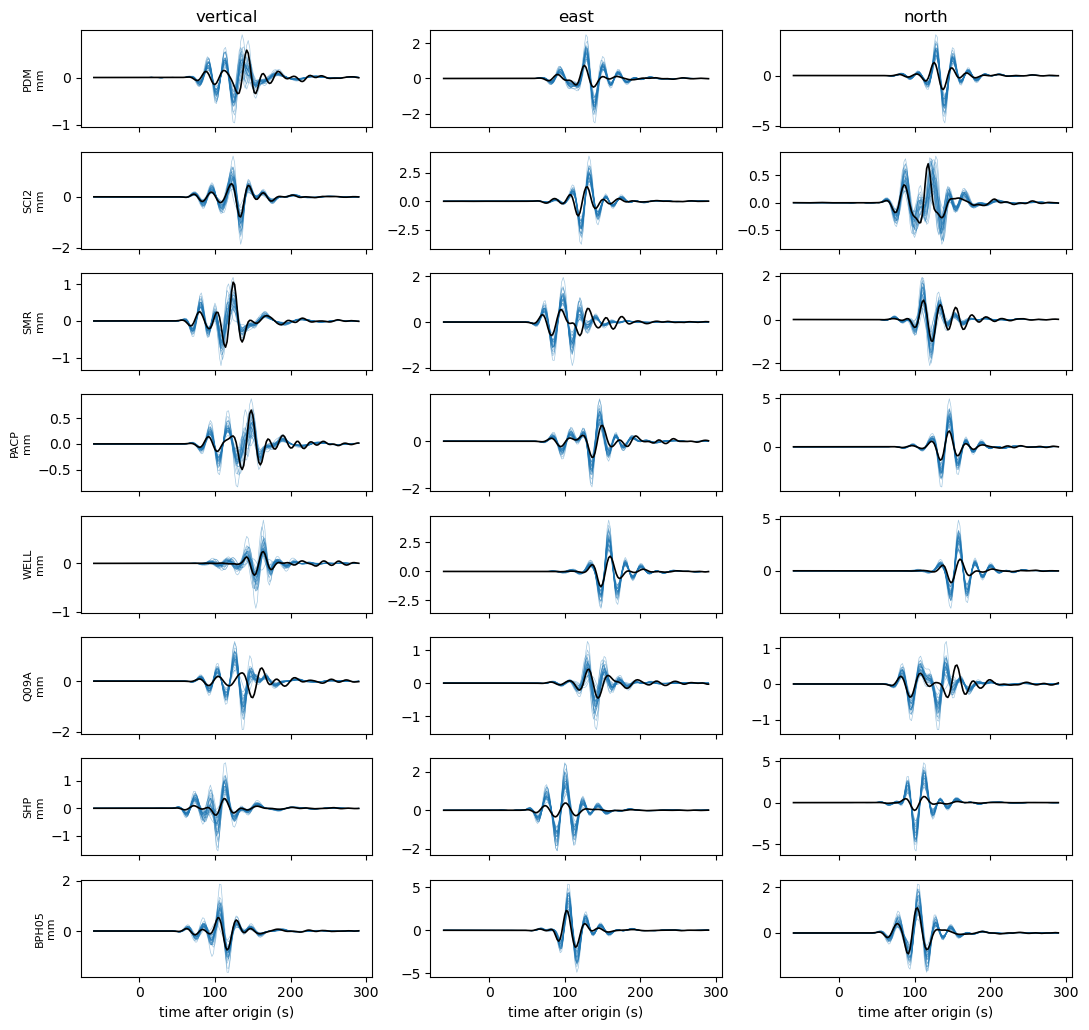

recorded data: misfit 1.23, above 100 % of the 130 held-out simulations recorded by seven or eight stations (their median 0.38): beyond the simulated support


In [12]:
predicted = np.einsum("ni,ijkl->njkl", npe_m6[:30], centroid_kernels)
fig, axes = plt.subplots(len(names), 3, figsize=(11, 1.3 * len(names)), sharex=True)
for station, row in enumerate(axes):
    for component, (ax, title) in enumerate(zip(row, ("vertical", "east", "north"))):
        ax.plot(time_s, predicted[:, station, component].T * 1e3, color="C0", lw=0.5, alpha=0.4)
        ax.plot(time_s, observed[station, component] * 1e3, color="k", lw=1.2)
        axes[0, component].set_title(title)
    row[0].set_ylabel(f"{names[station]}\nmm", fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel("time after origin (s)")
fig.tight_layout()
plt.show()
recorded_misfit = predictive_misfit(observed, range(len(names)), npe_m6[:20])
comparable = np.array([misfit for n_stations, misfit in misfits if n_stations >= len(names) - 1])
percentile = 100 * np.mean(comparable < recorded_misfit)
reading = "beyond" if percentile > 99 else "in the upper tail of" if percentile > 90 else "inside"
print(f"recorded data: misfit {recorded_misfit:.2f}, above {percentile:.0f} % of the {len(comparable)} held-out simulations "
      f"recorded by seven or eight stations (their median {np.median(comparable):.2f}): {reading} the simulated support")